In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve


LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local"


comap_maps = {
    "COMAP 26.5 GHz": "comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 27.5 GHz": "comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 28.5 GHz": "comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 29.5 GHz": "comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 30.5 GHz": "comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 31.5 GHz": "comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 32.5 GHz": "comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 33.5 GHz": "comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits"
}
comap_keys = list(comap_maps.keys())


effelsberg_maps = {
    "Effelsberg 1.43 GHz (10')":"EFFELSBERG-1.4285714285714286GHz-10.0amin.fits",
    "Effelsberg 1.43 GHz (15')":"EFFELSBERG-1.4285714285714286GHz-15.0amin.fits",
    "Effelsberg 1.43 GHz (20')":"EFFELSBERG-1.4285714285714286GHz-20.0amin.fits",
    "Effelsberg 1.43 GHz (25')":"EFFELSBERG-1.4285714285714286GHz-25.0amin.fits",
    "Effelsberg 1.43 GHz (30')":"EFFELSBERG-1.4285714285714286GHz-30.0amin.fits",
    "Effelsberg 1.43 GHz (60')":"EFFELSBERG-1.4285714285714286GHz-60.0amin.fits",
    "Effelsberg 2.73 GHz (5')":"EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",
    "Effelsberg 2.73 GHz (10')":"EFFELSBERG-2.7272727272727275GHz-10.0amin.fits",
    "Effelsberg 2.73 GHz (15')":"EFFELSBERG-2.7272727272727275GHz-15.0amin.fits",
    "Effelsberg 2.73 GHz (20')":"EFFELSBERG-2.7272727272727275GHz-20.0amin.fits",
    "Effelsberg 2.73 GHz (25')":"EFFELSBERG-2.7272727272727275GHz-25.0amin.fits",
    "Effelsberg 2.73 GHz (30')":"EFFELSBERG-2.7272727272727275GHz-30.0amin.fits",
    "Effelsberg 2.73 GHz (60')":"EFFELSBERG-2.7272727272727275GHz-60.0amin.fits"
}
effelsberg_keys = list(effelsberg_maps.keys())


gdigs_mosaics = {
    "GDIGS G017.50":"GDIGS_G017.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G022.50":"GDIGS_G022.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G027.25":"GDIGS_G027.25+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G030.80":"GDIGS_G030.80+00.00_halpha_2pol_average_moment0.fits"
}
gdigs_keys = list(gdigs_mosaics.keys())

nobeyama_maps = {

}


parkes_maps = {
    "PARKES 5GHz (5')":"PARKES-5.0GHz-5.0amin.fits",
    "PARKES 5GHz (10')":"PARKES-5.0GHz-10.0amin.fits"
}
parkes_keys = list(parkes_maps.keys())



In [ ]:
# Getting all the data

b_max = 1.1
b_min = -1.1
l_max = 40
l_min = 20

b_trackingerr = 0.78/60 # deg
l_trackingerr = 0.0/60 # deg

b_max = b_max - b_trackingerr
b_min = b_min - b_trackingerr
l_max = l_max - l_trackingerr
l_min = l_min - l_trackingerr

 # SNRs

snrs_data = np.genfromtxt(f"{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt", dtype="str", skip_header=3)
snrs_cutout = np.empty_like(snrs_data[0,:])
for r in snrs_data:
    if l_min < float(r[0]) < l_max and b_min < float(r[1]) < b_max:
        snrs_cutout = np.vstack((snrs_cutout, r))

snrs_cutout = snrs_cutout[1:,:] # removing empty first row

 # Comap maps

comap_data = {}
comap_noise = {}
comap_headers = {}
comap_wcs = {}

for key, fname in comap_maps.items():
    path = f"{LINUX_DIRECTORY}/data/comap_maps/{fname}"
    # path = f"data/comap_maps/{fname}"
    fits_file = fits.open(path)
    comap_data[key] = fits_file[0].data
    comap_noise[key] = 1/fits_file[3].data
    comap_headers[key] = fits_file[0].header
    comap_wcs[key] = WCS(comap_headers[key])

comap_cutouts = {} # will be: key:[data, noise]

for i, key in enumerate(comap_keys):
    upper_l, lower_b = comap_wcs[key].all_world2pix(l_min, b_min, 0)
    lower_l, upper_b = comap_wcs[key].all_world2pix(l_max, b_max, 0)
    # nrows, ncols = comap_data[key].shape
    # lower_b = max(0, min(nrows - 1, lower_b))
    # upper_b = max(0, min(nrows - 1, upper_b))
    # lower_l = max(0, min(ncols - 1, lower_l))
    # upper_l = max(0, min(ncols - 1, upper_l))

    cutout = comap_data[key][int(lower_b):int(upper_b)+1,
                             int(lower_l):int(upper_l)+1].copy()
    cutout_noise = comap_noise[key][int(lower_b):int(upper_b)+1,
                             int(lower_l):int(upper_l)+1].copy()
    cutout[cutout==np.nan] = 0
    comap_cutouts[key] = [cutout, cutout_noise]

    comap_wcs[key].wcs.crpix = [lower_l, lower_b]
    comap_wcs[key].wcs.crval = [l_min, b_min]

/tmp/ipykernel_10197/3583518380.py:38: RuntimeWarning: divide by zero encountered in divide
  comap_noise[key] = 1/fits_file[3].data


In [113]:
# Plotting
fig, axs = plt.subplots(len(comap_keys), 1, figsize=(13,2*len(comap_keys)),
                        dpi=300, subplot_kw={'projection': comap_wcs[comap_keys[0]]})

for i, map_key in enumerate(comap_keys):
    v_min = np.nanpercentile(cutout, 0.)
    v_max = np.nanpercentile(cutout, 99.5)

    ax = axs[i]
    im = ax.imshow(comap_cutouts[map_key][0], origin='lower', cmap='viridis', vmin = v_min,
                        vmax = v_max)
    for i, l in enumerate(snrs_cutout[:,0]):
        # snr_size = snrs_cutout[i][7]
        # if "x" in snr_size:
        #     snr_size = snr_size.split('x')
        #     snr_plotsize = np.max(np.array(snr_size, dtype=float))
        # else:
        #     snr_plotsize = float(snr_size)
        snr_l, snr_b = comap_wcs[comap_keys[0]].all_world2pix(float(l), float(snrs_cutout[i][1]), 0)
        ax.scatter(snr_l, snr_b, s=1)
    colours = plt.cm.Greys(np.linspace(0.0, 1.0, 7))
    ax.set_title(f"{map_key} (4.5 arcmin)")
    ax.set_xlabel("l [deg]")
    ax.set_ylabel("b [deg]")

    cbar = fig.colorbar(im, orientation='vertical')
    cbar.set_label("T_b [K]")

InvalidTransformError: ERROR 7 in wcsset() at line 2740 of file cextern/wcslib/C/wcs.c:
Ill-conditioned coordinate transformation parameter.
ERROR 4 in celset() at line 461 of file cextern/wcslib/C/cel.c:
Ill-conditioned coordinate transformation parameters
No valid solution for latp for these values of phip, phi0, and theta0.


<Figure size 3900x4800 with 0 Axes>

In [107]:
def rms(array):
    return np.sqrt(np.mean(np.square(array)))


def downsize_2D(arr, factor, combine_type='mean'):
    # print(arr)
    # first cut off excess
    combine_types = {
        'mean': np.mean,
        'rms': rms
    }

    row_cutoff = len(arr[0,:])%factor
    col_cutoff = len(arr[:,0])%factor

    arr = arr[col_cutoff:,row_cutoff:]
    # print(test_array)

    new_shape = (
        int(len(arr[:,0])/factor),
        int(len(arr[0,:])/factor)
    )
    downsized_array = np.empty(shape=new_shape)
    # print(downsized_array)
    for i in range(0, int(len(arr[:,0])/factor)):
        downsized_col = np.array([])
        for j in range(0, int(len(arr[0,:])/factor)):
            print(i,j)
            part = arr[i*factor:(i+1)*factor,
                       j*factor:(j+1)*factor]
            # print(part)
            # print(np.mean(part))
            downsized_array[i,j] = combine_types[combine_type.lower()](part)
    
    # print(downsized_array)
    return downsized_array



In [108]:
test_array = np.array([[1,2,3,4,5,4,3,2,2,np.nan,9,8,5],
            [6,7,8,9,10,42,3,6,5,3,5,3,9],
            [11,12,13,14,15,4,8,6,5,1,3,6,34],
            [16,17,18,19,20,6,1,9,78,12,3,5,3],
            [21,22,23,24,25,1,2,3,4,5,6,7,8],
            [1,2,3,4,5,4,3,2,1,0,9,8,5],
            [6,7,8,6,10,42,3,6,5,3,13,3,9],
            [11,12,13,14,15,4,8,6,5,1,3,6,34],
            [16,17,18,19,20,6,1,9,7,12,3,5,3],
            [21,22,23,24,25,1,2,3,4,5,6,7,8]])

print(downsize_2D(test_array, 5))

# repixelisation

repix_size = 4 # pixels

comap_repix = {}
comap_repixwcs = {}
for i, key in enumerate(comap_keys):
    repix_data = downsize_2D(comap_cutouts[key][0], repix_size)
    repix_noise = downsize_2D(comap_cutouts[key][1], repix_size, combine_type='rms')

    # Update WCS
    new_wcs = WCS(naxis=2)
    new_wcs.wcs.crval = comap_wcs[key].wcs.crval
    new_wcs.wcs.crpix = comap_wcs[key].wcs.crpix
    new_wcs.wcs.cdelt = np.array(comap_wcs[key].wcs.cdelt) *(repix_size)/2
    new_wcs.wcs.ctype = list(comap_wcs[key].wcs.ctype)

    # add to dicts
    comap_repix[key] = [repix_data, repix_noise]
    comap_repixwcs[key] = new_wcs


0 0
0 1
1 0
1 1
[[9.8   nan]
 [9.68 6.6 ]]
0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
0 100
0 101
0 102
0 103
0 104
0 105
0 106
0 107
0 108
0 109
0 110
0 111
0 112
0 113
0 114
0 115
0 116
0 117
0 118
0 119
0 120
0 121
0 122
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
0 145
0 146
0 147
0 148
0 149
0 150
0 151
0 152
0 153
0 154
0 155
0 156
0 157
0 158
0 159
0 160
0 161
0 162
0 163
0 164
0 165
0 166
0 167
0 168
0 169
0 170
0 171
0 172
0 173
0 174
0 175
0 176
0 177

10 147
10 148
10 149
10 150
10 151
10 152
10 153
10 154
10 155
10 156
10 157
10 158
10 159
10 160
10 161
10 162
10 163
10 164
10 165
10 166
10 167
10 168
10 169
10 170
10 171
10 172
10 173
10 174
10 175
10 176
10 177
10 178
10 179
10 180
10 181
10 182
10 183
10 184
10 185
10 186
10 187
10 188
10 189
10 190
10 191
10 192
10 193
10 194
10 195
10 196
10 197
10 198
10 199
10 200
10 201
10 202
10 203
10 204
10 205
10 206
10 207
10 208
10 209
10 210
10 211
10 212
10 213
10 214
10 215
10 216
10 217
10 218
10 219
10 220
10 221
10 222
10 223
10 224
10 225
10 226
10 227
10 228
10 229
10 230
10 231
10 232
10 233
10 234
10 235
10 236
10 237
10 238
10 239
10 240
10 241
10 242
10 243
10 244
10 245
10 246
10 247
10 248
10 249
10 250
10 251
10 252
10 253
10 254
10 255
10 256
10 257
10 258
10 259
10 260
10 261
10 262
10 263
10 264
10 265
10 266
10 267
10 268
10 269
10 270
10 271
10 272
10 273
10 274
10 275
10 276
10 277
10 278
10 279
10 280
10 281
10 282
10 283
10 284
10 285
10 286
10 287
10 288
10 289

In [109]:
print(new_wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CAR' 'GLAT-CAR' 
CRVAL : 110.0 0.0 
CRPIX : -4199.0168000672 67.78026712106848 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0333332 0.0333332 
NAXIS : 0  0


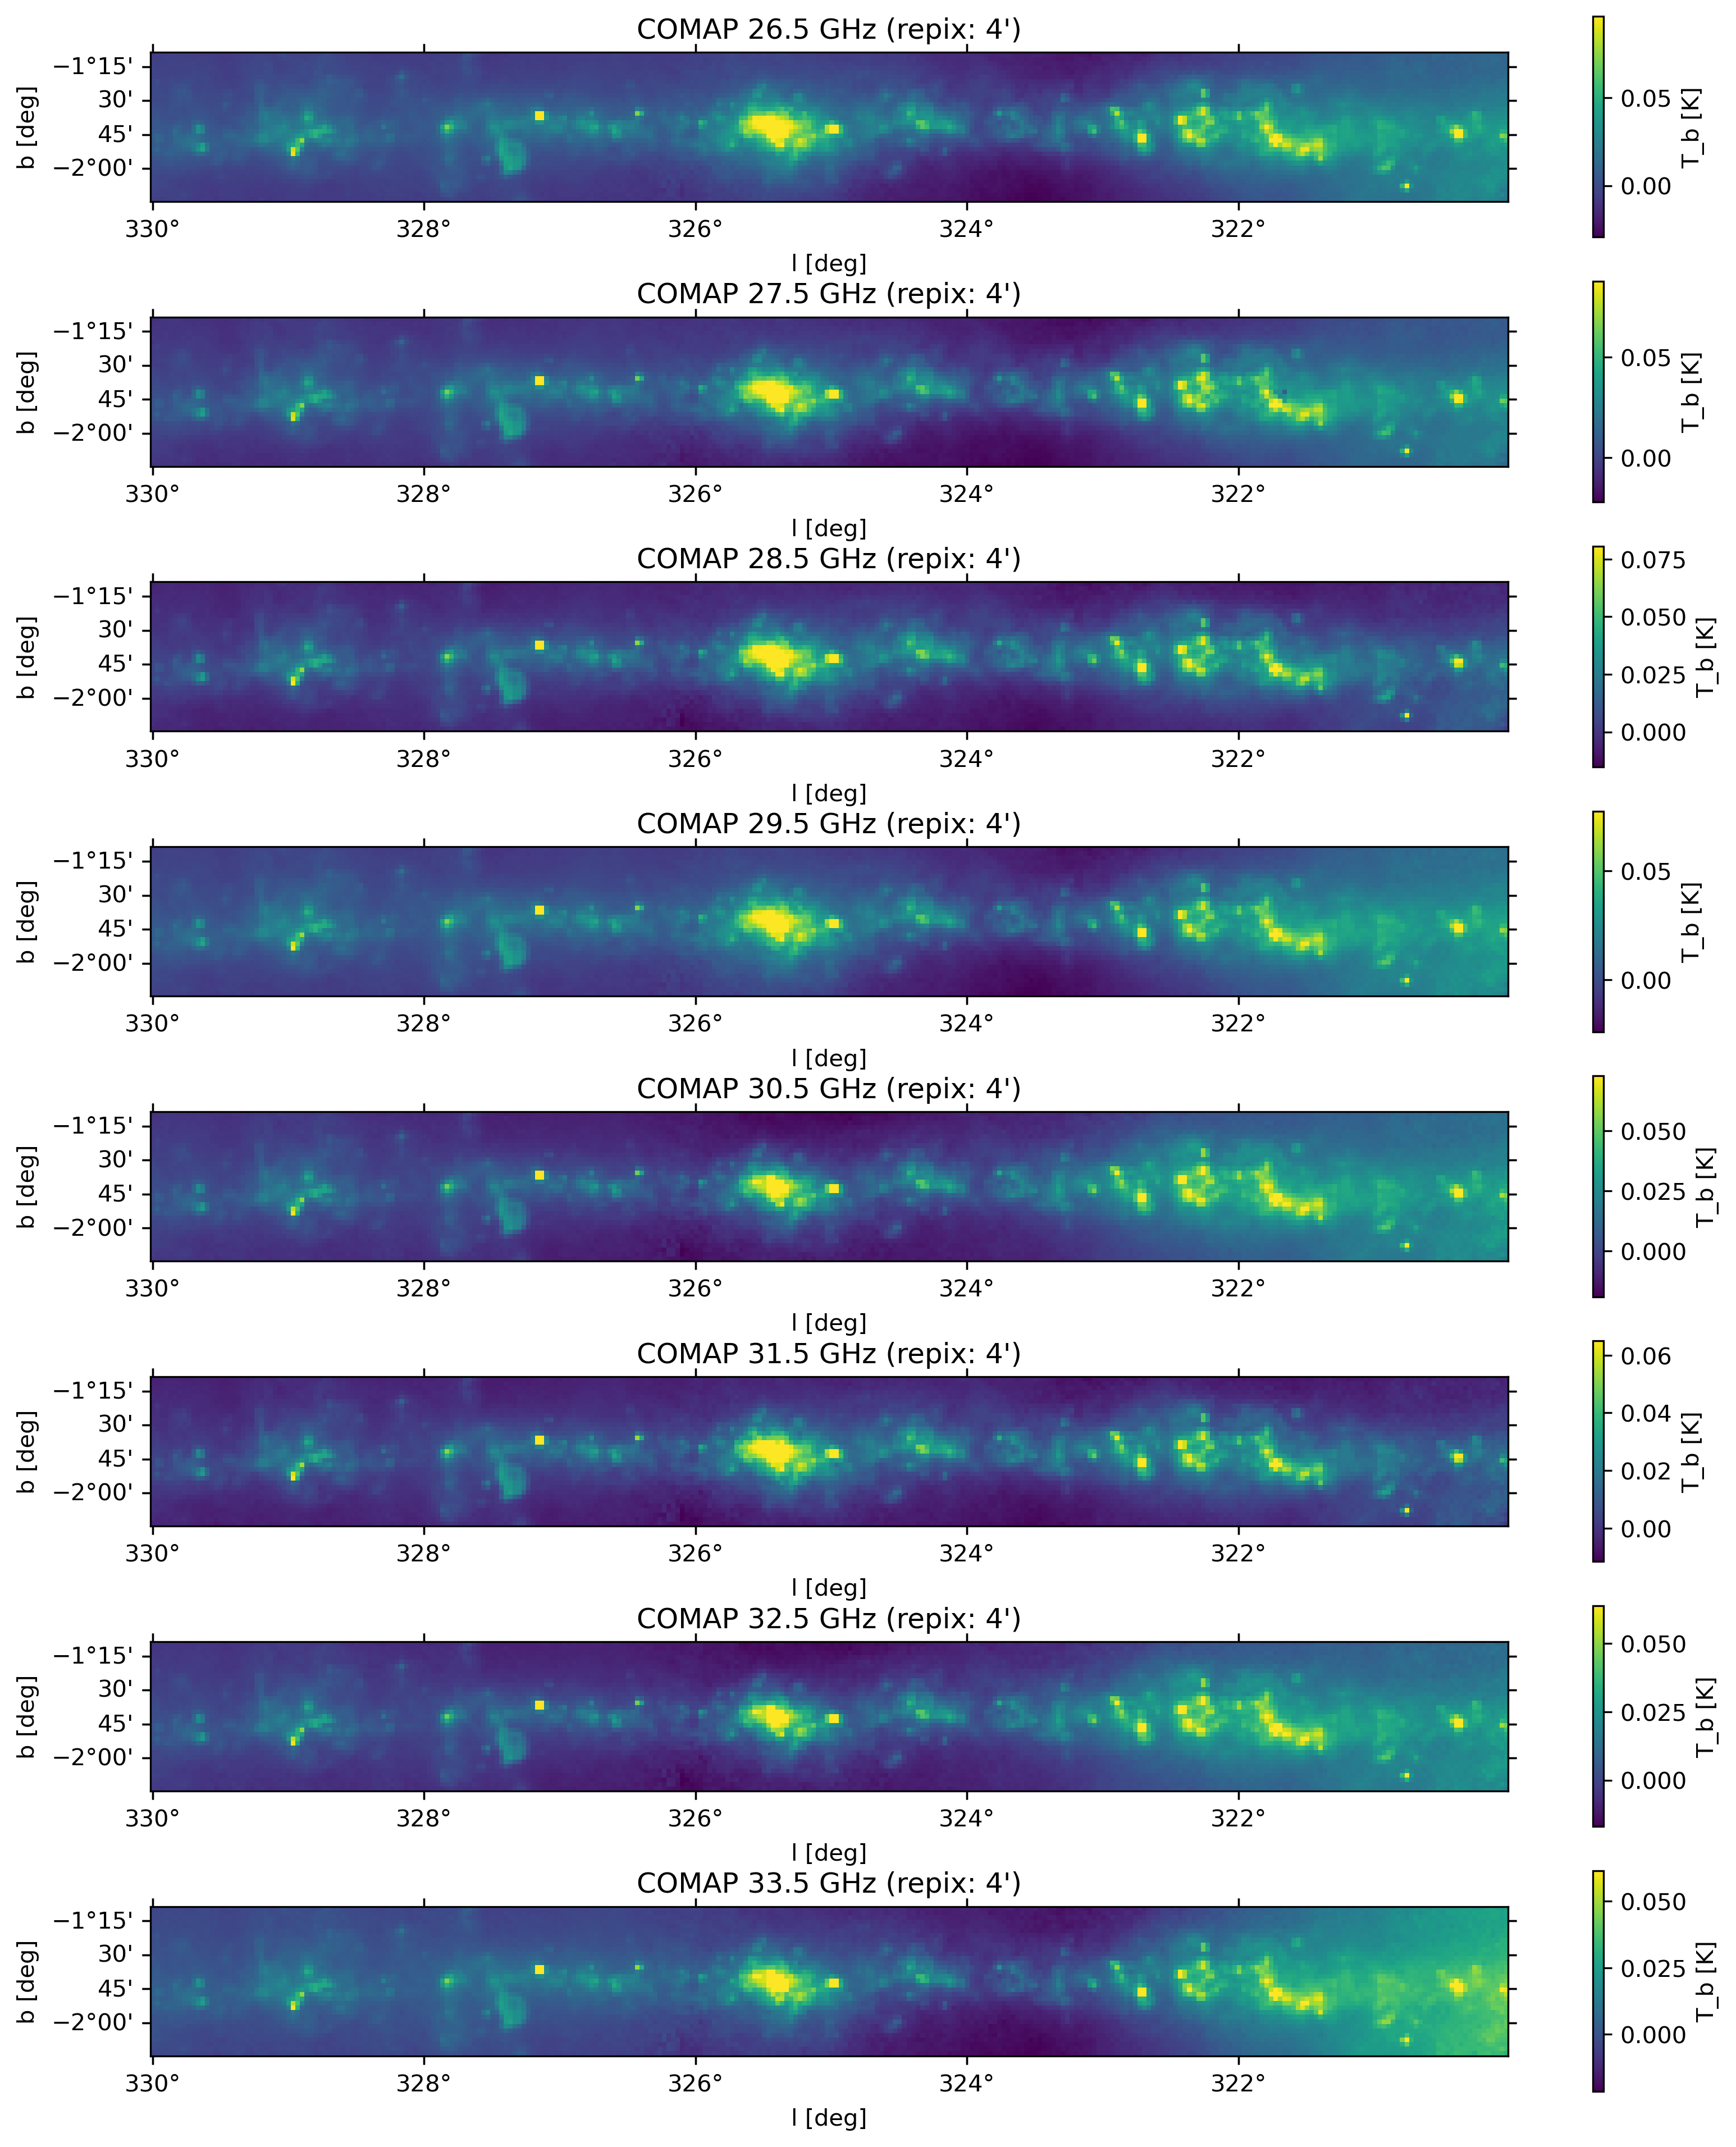

In [110]:
# Plotting repixelised maps

fig, axs = plt.subplots(len(comap_keys), 1, figsize=(13,2*len(comap_keys)),
                        dpi=300,
                        subplot_kw={'projection': comap_repixwcs[comap_keys[0]]}
                        )

for i, map_key in enumerate(comap_keys):
    v_min = np.nanpercentile(comap_repix[map_key][0], 0.)
    v_max = np.nanpercentile(comap_repix[map_key][0], 99.5)

    ax = axs[i]
    im = ax.imshow(comap_repix[map_key][0], origin='lower', cmap='viridis', vmin = v_min,
                        vmax = v_max)
    # for i, l in enumerate(snrs_cutout[:,0]):
    #     # snr_size = snrs_cutout[i][7]
    #     # if "x" in snr_size:
    #     #     snr_size = snr_size.split('x')
    #     #     snr_plotsize = np.max(np.array(snr_size, dtype=float))
    #     # else:
    #     #     snr_plotsize = float(snr_size)
    #     snr_l, snr_b = comap_wcs[comap_keys[0]].all_world2pix(float(l), float(snrs_cutout[i][1]), 0)
    #     ax.scatter(snr_l, snr_b, s=1)
    ax.set_title(f"{map_key} (repix: {repix_size}')")
    ax.set_xlabel("l [deg]")
    ax.set_ylabel("b [deg]")

    cbar = fig.colorbar(im, orientation='vertical')
    cbar.set_label("T_b [K]")

plt.show()

In [111]:
# smoothing

comap_smooth = {}
